# Experiment 5.4.1 — direct WHAT base + constrained WHAT×WHEN residual

Analysis-only notebook for `direct_what_conjunction_residual_v2`. The base classifier reads the original frozen WHAT L2 spikes directly (`direct_what_wholecount`); the residual branch can add evidence only through a structural WHAT×WHEN conjunction.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / 'notebooks').is_dir():
    repo_root = repo_root.parent
root = repo_root / 'notebooks' / 'artifacts' / 'experiment_5_4_1_constrained_conjunction_residual' / 'direct_what_conjunction_residual_v2'
base_runs = pd.read_csv(root / 'base_runs.csv')
base_histories = pd.read_csv(root / 'base_histories.csv')
runs = pd.read_csv(root / 'runs.csv')
histories = pd.read_csv(root / 'histories.csv')
ablations = pd.read_csv(root / 'ablation_runs.csv')
activity = pd.read_csv(root / 'activity_runs.csv')
paired = pd.read_csv(root / 'paired_deltas.csv')
manifest = json.loads((root / 'manifest.json').read_text(encoding='utf-8'))
manifest


{'ablations': ['ordered',
  'reset_when',
  'when_zero',
  'when_shuffle',
  'when_circular_shift',
  'residual_what_zero'],
 'aggregation_policy': 'finalizer only aggregates existing base/residual artifacts; no training or cache regeneration',
 'architecture_contract': 'WHAT128 -> direct bias-free Linear12 -> non-leaky valid-time accumulator + one class bias; in parallel, WHAT128 -> selector128 AND frozen WHEN64 -> selector128 -> conjunction128 -> bias-free residual Linear12 -> accumulator',
 'base_condition': 'direct_what_wholecount',
 'baseline_preservation': 'freeze trained direct WHAT base; zero-initialize residual output; epoch 0 exactly equals direct WHAT base',
 'context_temporal_state': False,
 'expected_base_runs': 5,
 'expected_residual_runs': 5,
 'experiment_id': 'experiment_5_4_1_constrained_conjunction_residual',
 'extra_fusion_lif_between_what_and_base': False,
 'files': {'ablation_runs': 'ablation_runs.csv',
  'activity_runs': 'activity_runs.csv',
  'base_histories': 'b

## Direct WHAT base versus constrained residual

The primary paired quantity is residual-model test BA minus the direct whole-count readout of the exact same frozen WHAT spike trajectory.


In [2]:
summary = pd.DataFrame({
    'base_condition': ['direct_what_wholecount'],
    'base_ba_mean': [base_runs['test_balanced_accuracy'].mean()],
    'base_ba_sd': [base_runs['test_balanced_accuracy'].std()],
    'residual_ba_mean': [runs['test_balanced_accuracy'].mean()],
    'residual_ba_sd': [runs['test_balanced_accuracy'].std()],
    'delta_vs_base_mean': [runs['delta_test_ba_vs_base'].mean()],
    'delta_vs_base_sd': [runs['delta_test_ba_vs_base'].std()],
    'wins_vs_base': [int((runs['delta_test_ba_vs_base'] > 0).sum())],
    'epoch0_selected': [int((runs['best_epoch'] == 0).sum())],
})
summary


,base_condition,base_ba_mean,base_ba_sd,residual_ba_mean,residual_ba_sd,delta_vs_base_mean,delta_vs_base_sd,wins_vs_base,epoch0_selected
0,direct_what_wholecount,0.471423,0.027293,0.469828,0.037587,-0.001595,0.016842,3,1


In [3]:
paired_summary = pd.DataFrame({
    'delta_ba_mean': [paired['delta_test_balanced_accuracy'].mean()],
    'delta_ba_sd': [paired['delta_test_balanced_accuracy'].std()],
    'wins': [int((paired['delta_test_balanced_accuracy'] > 0).sum())],
    'delta_macro_f1_mean': [paired['delta_test_macro_f1'].mean()],
})
paired_summary


,delta_ba_mean,delta_ba_sd,wins,delta_macro_f1_mean
0,-0.001595,0.016842,3,-0.002674


## History/alignment attribution

`when_zero` and `residual_what_zero` are hard structural controls: residual evidence must be zero and final predictions must recover the frozen direct WHAT base. Ordered-vs-reset/shuffle/circular-shift tests whether any gain depends on history and temporal alignment.


In [4]:
ablation_summary = (
    ablations.groupby('ablation', as_index=False)
    .agg(
        test_ba_mean=('test_balanced_accuracy', 'mean'),
        test_ba_sd=('test_balanced_accuracy', 'std'),
        residual_abs_mean=('residual_mean_abs_logit', 'mean'),
        residual_abs_max=('residual_abs_max', 'max'),
        conjunction_fr_mean=('conjunction_firing_fraction', 'mean'),
    )
    .sort_values('test_ba_mean', ascending=False)
)
ablation_summary


,ablation,test_ba_mean,test_ba_sd,residual_abs_mean,residual_abs_max,conjunction_fr_mean
1,reset_when,0.471423,0.027293,0.000346,0.147156,0.000002
2,residual_what_zero,0.471423,0.027293,0.000000,0.000000,0.000000
5,when_zero,0.471423,0.027293,0.000000,0.000000,0.000000
4,when_shuffle,0.471113,0.028009,0.471680,20.567341,0.128266
0,ordered,0.469828,0.037587,0.639187,22.363264,0.162538
3,when_circular_shift,0.464704,0.030397,0.471994,18.949665,0.116786


In [5]:
ordered = ablations[ablations['ablation'] == 'ordered'].set_index('seed')
alignment_rows = []
for name in ('reset_when', 'when_shuffle', 'when_circular_shift'):
    control = ablations[ablations['ablation'] == name].groupby('seed')['test_balanced_accuracy'].mean()
    delta = ordered['test_balanced_accuracy'] - control
    alignment_rows.append({
        'ablation': name,
        'aligned_minus_ablation_ba_mean': delta.mean(),
        'aligned_minus_ablation_ba_sd': delta.std(),
        'aligned_wins': int((delta > 0).sum()),
    })
alignment = pd.DataFrame(alignment_rows)
alignment


,ablation,aligned_minus_ablation_ba_mean,aligned_minus_ablation_ba_sd,aligned_wins
0,reset_when,-0.001595,0.016842,3
1,when_shuffle,-0.001285,0.008982,4
2,when_circular_shift,0.005124,0.013815,2


In [6]:
zero_checks = ablations[ablations['ablation'].isin(['when_zero', 'residual_what_zero'])]
zero_checks.groupby('ablation', as_index=False).agg(
    residual_abs_max=('residual_abs_max', 'max'),
    conjunction_fr_max=('conjunction_firing_fraction', 'max'),
    test_ba_mean=('test_balanced_accuracy', 'mean'),
)


,ablation,residual_abs_max,conjunction_fr_max,test_ba_mean
0,residual_what_zero,0.0,0.0,0.471423
1,when_zero,0.0,0.0,0.471423


## Base and residual training dynamics


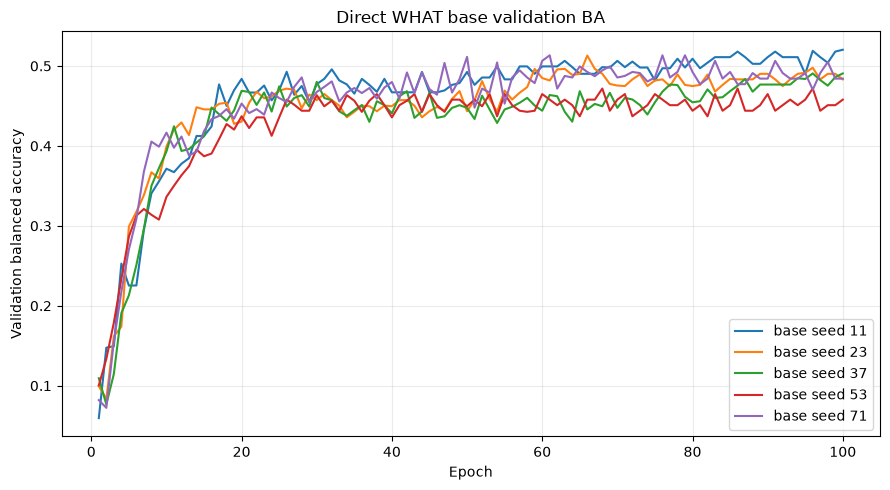

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for seed, group in base_histories.groupby('seed'):
    ax.plot(group['epoch'], group['val_balanced_accuracy'], label=f'base seed {seed}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation balanced accuracy')
ax.set_title('Direct WHAT base validation BA')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()


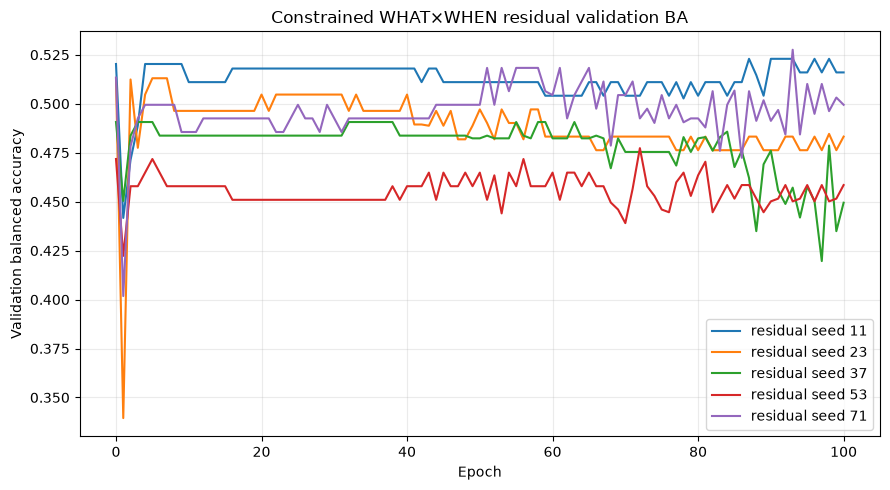

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for seed, group in histories.groupby('seed'):
    ax.plot(group['epoch'], group['val_balanced_accuracy'], label=f'residual seed {seed}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation balanced accuracy')
ax.set_title('Constrained WHAT×WHEN residual validation BA')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()


## Interpretation checklist

Support requires positive paired BA over `direct_what_wholecount`, ordered WHEN outperforming reset/shuffled/shifted controls, and exact zero residual under either missing conjunction side. If `epoch0_selected` is high, the correct conclusion is that the frozen WHEN representation did not add reliable incremental classification value beyond direct WHAT evidence.
